In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [8]:
# Récupération des données dans le fichier
df = pd.read_csv("C:/Users/ncuss/Desktop/ENSTA/Ondocean_Hybridation_INS_VOR_DME_V1/data.csv")

# On constitue la vérité terrain de la trajectoire et le time-tick de l'enregistrement
reference_tempo=[]
timer_tempo=[]
for k in df.index:
    reference_tempo.append([df['__lon__deg'][k],df['__lat__deg'][k],df['__altftmsl'][k],df['__mag_comp'][k]])
    timer_tempo.append(df['missn_time'][k])
reference = np.stack(reference_tempo)
timer = np.stack(timer_tempo)

# On extrait également les mesures VOR, DME et ADF
mesures=[]
for k in df.index:
    mesures.append([df['_freqNAV_1'][k],df['r-brgNAV_1'][k],df['dme-dNAV_1'][k],df['_freqNAV_2'][k],df['r-brgNAV_2'][k],df['dme-dNAV_2'][k],df['_freqADF_1'][k],df['r-brgADF_1'][k]])

    #timer_tempo.append(df['missn_time'][k])
mesures = np.stack(mesures)

# On créé aussi la base de données des balises de radionavigation
# Pour chaque entrée : Fréquence, Indicatif, type, X, Y, Z
donnees_balises = {
    "11145" : ["DJL", "VORDME", 47.16148, 5.05504, 200],
    "11735" : ["RLP", "VORDME", 47.54227, 5.14570, 200],
    "10820" : ["LXI", "DME", 47.46594, 6.21256, 200],
    "11300" : ["EPL", "VOR", 48.19042, 6.03339, 200],
    "11710" : ["LUL", "VOR", 47.41178, 6.17441, 200],
}


In [9]:
print(mesures[905])
freq = 1.1145e4
print(donnees_balises[str(int(freq))])


[ 1.11450e+04  0.00000e+00 -2.45272e+00  1.08200e+04  0.00000e+00
 -2.50000e+00  0.00000e+00  0.00000e+00]
['DJL', 'VORDME', 47.16148, 5.05504, 200]


In [10]:
# Creation de l'EKF
# Vecteur d'état : X,Y,Z,theta, V
#                  0,1,2,  3  , 4
# Attention aux unités : X,Y en coordonnées GEO, Z en ft AMSL, Theta en degrés magnétiques et V en kts.

# Initialisation du vecteur d'état et de la matrice de covariance
X = [reference[0,1],reference[0,0],reference[0,2],reference[0,3],100] # Initialiser avec les valeurs sorties du fichier et 100 kt pour la vitesse.
P = np.zeros([5,5])
# J'initialise X avec les valeurs extraites du premier échantillon. Elles sont donc très bonnes. 
# Je rajoute seulement un peu de bruit sur la vitesse.
P[0,0] = 0.5
P[1,1] = 0.5
P[2,2] = 0.5
P[3,3] = 0.5
P[4,4] = 5

# Covariance de bruit de modèle
Q = np.zeros([5,5])
Q[0,0] = 0.5
Q[1,1] = 0.5
Q[2,2] = 200
Q[3,3] = 90
Q[4,4] = 5

# Fonction (non-linéraire) de propagation
def f(X,timer,k):
    X_pred = np.zeros(5)
    delta_T = timer[k] - timer[k-1]
    X_pred[0] = X[0] + (X[4]/3600*np.cos(np.radians(X[3]))*delta_T*np.cos(np.radians(X[1])))/60
    X_pred[1] = X[1] + (X[4]/3600*np.sin(np.radians(X[3]))*delta_T)/60
    X_pred[2] = X[2]
    X_pred[3] = X[3]
    X_pred[4] = X[4]
    return X_pred

# Fonctions non linéraires de mesure
def h_distance(X, donnees_balise):
    distance = 0
    # Rayon moyen de la Terre en mètres
    rayon_terre = 6371000
    # Conversion des différences de longitude et latitude en distances
    dX = np.radians(X[0] - donnees_balise[3]) * rayon_terre * np.cos(np.radians((X[1] + donnees_balise[2]) / 2))
    dY = np.radians(X[1] - donnees_balise[2]) * rayon_terre
    dZ = X[2] - donnees_balise[4]
    # Calcul de la distance euclidienne
    distance = np.sqrt(dX**2 + dY**2 + dZ**2)
    return distance

def h_radial(X, donnees_balise):
    # Rayon moyen de la Terre en mètres
    rayon_terre = 6371000
    # Conversion des latitudes et longitudes en radians
    Y_moy_rad = np.radians((X[1] + donnees_balise[2]) / 2)
    # Conversion des différences de longitude et latitude en distances
    dX = np.radians(X[0] - donnees_balise[3]) * rayon_terre * np.cos(Y_moy_rad)
    dY = np.radians(X[1] - donnees_balise[2]) * rayon_terre
    # Calcul du radial en radians
    radial_rad = np.arctan2(dX, dY)
    # Conversion en degrés
    radial_deg = np.degrees(radial_rad)
    # Le radial est mesuré par rapport au nord, donc on ajuste pour obtenir un angle entre 0 et 360 degrés
    radial_deg = radial_deg % 360
    return radial_deg

# Fonctions de calcul des lignes de la jacobienne (le nombre de mesure est dynamique)
def H_ligne_dme(X, donnees_balise):
        # Calcul des différences
    dX = X[0] - donnees_balise[3]
    dY = X[1] - donnees_balise[2]
    dZ = X[2] - donnees_balise[4]
    # Calcul de la distance DME
    distance = np.sqrt(dX**2 + dY**2 + dZ**2)
    # Dérivées partielles
    dhdX = dX / distance
    dhdY = dY / distance
    dhdZ = dZ / distance
    dhdTheta = 0.0
    dhdV = 0.0
    # Ligne de la matrice jacobienne H
    H_ligne_dme = [dhdX, dhdY, dhdZ, dhdTheta, dhdV]
    return H_ligne_dme

def H_ligne_radial(X, donnees_balise):
    # Rayon moyen de la Terre en mètres
    rayon_terre = 6371000
    # Conversion des latitudes en radians
    Y_moy_rad = np.radians((X[1] + donnees_balise[2]) / 2)
    # Conversion des différences de longitude et latitude en distances
    dX = (X[0] - donnees_balise[3]) * rayon_terre * np.cos(Y_moy_rad)
    dY = (X[1] - donnees_balise[2]) * rayon_terre
    # Calcul du dénominateur commun
    denominator = dX**2 + dY**2
    # Dérivée par rapport à X (longitude)
    dhdX = (rayon_terre * np.cos(Y_moy_rad) * dY) / denominator
    # Dérivée par rapport à Y (latitude)
    dhdY = (-rayon_terre * dX) / denominator + (rayon_terre * (X[0] - donnees_balise[3]) * np.sin(Y_moy_rad) * dY) / (2 * denominator)
    # Dérivée par rapport à Z (altitude)
    dhdZ = 0.0
    # Dérivée par rapport à theta (cap)
    dhdTheta = 0.0
    # Dérivée par rapport à V (vitesse)
    dhdV = 0.0
    # Ligne de la matrice jacobienne H
    H_row = [dhdX, dhdY, dhdZ, dhdTheta, dhdV]
    return H_row

print(reference[0,0])
print(reference[0,1])

5.07231
47.44106


In [11]:
# Filtre proprement dit
X_traque = []
X_traque.append(X)
P_traque = []
P_traque.append(P)
H_traque = []
K_traque = []

for i in range(1,5): #timer.shape[0]-1):
    # Etat prédit
    X_pred = f(X,timer,i)

    # Calcul de la jacobienne F
    F = np.zeros([5,5])
    delta_T = timer[i] - timer[i-1]
    for k in range(0,5):
        F[k,k] = 1
    # Composante derivée partielle de X    
    F[0,1] = - (X[4] * np.cos(np.radians(X[3])) * delta_T * np.sin(np.radians(X[1]))) / (3600*60)
    F[0,3] = -X[4]/3600*np.sin(np.radians(X[3]))*delta_T*np.cos(np.radians(X[1]))/60
    F[0,4] = np.cos(np.radians(X[3]))*delta_T*np.cos(np.radians(X[1]))/(3600*60)
    # Composante derivée partielle de Y    
    F[1,3] = X[4]/(3600*60)*np.cos(np.radians(X[3]))*delta_T
    F[1,4] = np.sin(np.radians(X[3]))*delta_T/(3600*60)

    #Calcul de la covariance d'état estimé
    P_pred = F@P@F.T+Q

    # Calcul de la jacobienne H 
    H = []
    z = []
    r = []
    valeur_h = []
    # Radial VOR de la NAV1
    if int(mesures[i][1]) != 0:
        H.append(H_ligne_radial(X,donnees_balises[str(int(mesures[i][0]))]))
        z.append(int(mesures[i][1]))
        r.append(2)
        valeur_h.append(h_radial(X, donnees_balises[str(int(mesures[i][0]))]))
    # Radial VOR de la NAV2
    if int(mesures[i][4]) != 0:
        H.append(H_ligne_radial(X,donnees_balises[str(int(mesures[i][3]))]))
        z.append(int(mesures[i][4]))
        r.append(2)
        valeur_h.append(h_radial(X, donnees_balises[str(int(mesures[i][3]))]))
    # DME NAV 1
    if int(mesures[i][2]) > 0:
        H.append(H_ligne_dme(X,donnees_balises[str(int(mesures[i][0]))]))
        z.append(int(mesures[i][2]))
        r.append(0.5)
        valeur_h.append(h_distance(X, donnees_balises[str(int(mesures[i][0]))]))
    # DME NAV 2
    if int(mesures[i][5]) > 0:
        H.append(H_ligne_dme(X,donnees_balises[str(int(mesures[i][3]))]))
        z.append(int(mesures[i][5]))
        r.append(0.5)
        valeur_h.append(h_distance(X, donnees_balises[str(int(mesures[i][3]))]))
    # Les NDB ne sont pas implémentés pour le moment
    
    # On transforme les listes en vecteurs
    H = np.stack(H)
    z = np.stack(z)
    r = np.stack(r)
    valeur_h = np.stack(valeur_h)
    # On stocke H pour mémoire
    H_traque.append(H)

    # Covariance du bruit de mesure :
    R = np.identity(len(z))
    R = R@r

    # Calcul du gain de Kalman
    facteur_gain = H@P_pred@H.T + R
    inversee = np.linalg.inv(facteur_gain)
    K = P_pred@H.T@inversee

    # Correction de l'état prédit
    X_corrige = X_pred + K@(z-valeur_h)

    # Nouvelle covariance d'état
    P_corrige = P_pred - K@H@P_pred

    # Mise à jour de l'état
    X_traque.append(X_corrige)
    P_traque.append(P_corrige)
    X = X_corrige
    P = P_corrige

    print(i)
X_traque = np.stack(X_traque)


1
2
3
4


In [12]:
print(X_traque[3])

[  50.30746102   48.76006676 2780.0498      167.32388042  100.0000361 ]


IndexError: index 550 is out of bounds for axis 0 with size 5

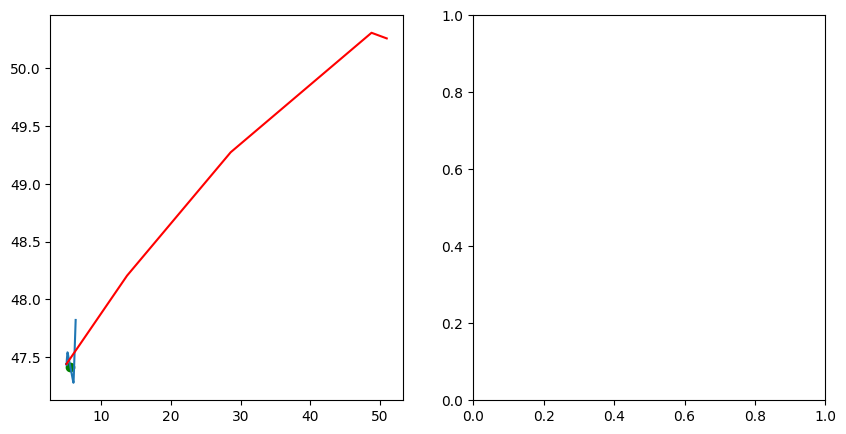

In [13]:
# Test d'impression de la trajectoire de référence
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)
ax1.plot(reference[:,0], reference[:,1])
ax1.plot(X_traque[:,1], X_traque[:,0], c='red')

# Le testeur pour les valeurs en X,Y
k = 550
ax1.scatter(reference[k,0], reference[k,1], c="green")
ax1.scatter(X_traque[k,1], X_traque[k,0], c="purple")


# La voie Z
ax2.plot(timer[:], reference[:,2])
